<a href="https://colab.research.google.com/github/MNTech955/100-days-of-machine-learning/blob/main/Principle__Component__Analysis_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

# New code (pandas 2.x compatible)
df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)


df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [4]:

import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [5]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [6]:
# df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]
# df.iloc → integer-location based indexing in pandas
# : → all rows
# 0,1,2 → first, second, and third columns of your dataframe
# So [df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]] → a list of three arrays, each representing one column’s data

# Example: If your columns are feature1, feature2, feature3, this selects the data of all three features.
# np.cov() → NumPy function to calculate the covariance matrix
# Covariance measures how two variables vary together:
# Positive covariance → both increase together
# Negative covariance → one increases while other decreases
# Near 0 → variables are almost independent

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)


In [8]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [9]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

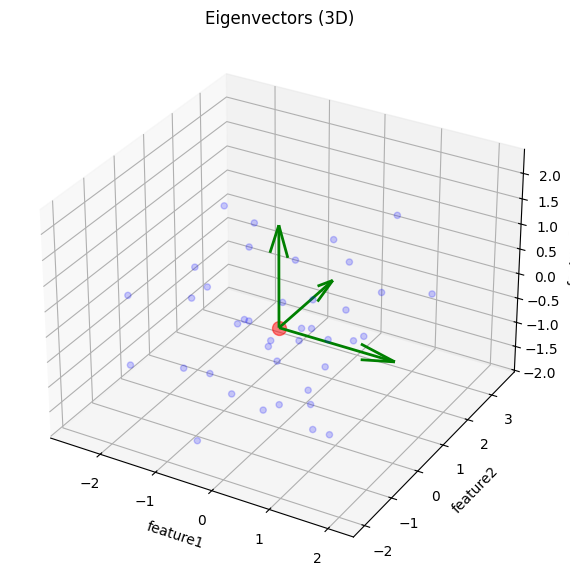

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.scatter(df['feature1'], df['feature2'], df['feature3'], color='blue', alpha=0.2)

# Mean point
mean_point = [df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()]
ax.scatter(*mean_point, color='red', s=100, alpha=0.5)

# Eigenvectors example (u can calculate real eigenvectors)
eigen_vectors = np.eye(3)  # just example: identity matrix as vectors
for v in eigen_vectors.T:
    ax.quiver(mean_point[0], mean_point[1], mean_point[2],
              v[0], v[1], v[2], length=2, color='green', linewidth=2)

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')
plt.title('Eigenvectors (3D)')
plt.show()

In [19]:
# Select top 2 eigenvectors (corresponding to the two largest eigenvalues)
# What happens here:
# eigen_vectors is a 3×3 matrix because we have 3 features.
# [[v11, v12, v13],
#  [v21, v22, v23],
#  [v31, v32, v33]]
# Each column is an eigenvector corresponding to an eigenvalue.
# The first column [:,0] corresponds to the largest eigenvalue → direction of max variance.
# The second column [:,1] corresponds to the second largest eigenvalue → second most variance.
# [:, 0:2] means all rows, columns 0 and 1 → we get a 3×2 matrix (features × top 2 PCs).
# Result:
# Matrix pc looks like:
# [[-0.538, -0.694],
#  [-0.656, -0.011],
#  [-0.528,  0.720]]
# 3 rows → original features
# 2 columns → top 2 principal components

# This matrix will be used to project the 3D data into 2D.
pc = eigen_vectors[:, 0:2]  # shape (n_features, 2)

# Project the original 3D data onto the 2 principal components
# Explanation:

# df.iloc[:, :3] → select all rows and the first 3 columns (the original 3 features). Shape = (n_samples, 3).
# np.dot() performs matrix multiplication.


# Matrix multiplication math:
# [ n_samples x 3 ] dot [ 3 x 2 ] = [ n_samples x 2 ]
# Each row of your original data is a 3D point [x1, x2, x3].
# Multiplying by pc projects this 3D point onto the 2 principal components:
# PC1 = x1*v11 + x2*v21 + x3*v31
# PC2 = x1*v12 + x2*v22 + x3*v32
# Result: a new array transformed_df where each data point is now represented in the 2D PCA space.
transformed_df = np.dot(df.iloc[:, :3], pc)  # shape (n_samples, 2)
# Summary Intuition:

# Original 3D point → [x1, x2, x3]
# Top 2 eigenvectors → 2D axes capturing most variance
# Dot product → project 3D point into 2D PCA space [PC1, PC2]
# Now your data is compressed but information-rich in 2 dimensions
# Create new DataFrame
new_df = pd.DataFrame(transformed_df, columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,2.302877,-0.757593,1
1,0.524464,0.520221,0
2,0.380275,-0.459443,1
3,0.534262,-1.773773,1
4,1.610434,1.747819,1


In [20]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()